In addition to the metal composition features, the Category (Cat1–Cat4) column was also included in the model by applying one-hot encoding. However, the feature importance analysis showed that the category variable had very minimal influence on the prediction of recoverability.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
data = pd.read_csv('e_waste_cleaned_recoverable.csv')
data.head(5)

,Item,Category,Gold,Silver,Platinum,Rhodium,Nickel,Tin,Lithium,Aluminum,Carbon,Profit ($),Total_Value,Recoverable
0,iPhone 11,Cat3,3.58,2.95,1.73,8.92,1.91,1.01,1.82,1.27,9.51,270.34,1747.586811,1
1,Toaster,Cat2,7.21,4.31,6.21,5.63,9.59,7.65,0.51,3.03,4.22,689.75,1827.215202,1
2,Speaker,Cat4,8.91,5.09,2.42,7.70,1.09,1.49,7.42,3.63,8.83,570.43,1946.945103,1
3,Microwave Oven,Cat2,2.62,3.84,2.98,7.66,9.41,2.25,7.84,6.18,6.36,290.78,1595.124886,0
4,Air Conditioner,Cat1,3.47,3.89,6.20,4.35,5.07,8.65,8.62,0.82,5.53,505.16,1395.768663,0


In [85]:
X = data.drop(columns=["Total_Value", "Profit ($)","Recoverable", "Item"])
y = data["Recoverable"]

In [86]:
X.head()

,Category,Gold,Silver,Platinum,Rhodium,Nickel,Tin,Lithium,Aluminum,Carbon
0,Cat3,3.58,2.95,1.73,8.92,1.91,1.01,1.82,1.27,9.51
1,Cat2,7.21,4.31,6.21,5.63,9.59,7.65,0.51,3.03,4.22
2,Cat4,8.91,5.09,2.42,7.70,1.09,1.49,7.42,3.63,8.83
3,Cat2,2.62,3.84,2.98,7.66,9.41,2.25,7.84,6.18,6.36
4,Cat1,3.47,3.89,6.20,4.35,5.07,8.65,8.62,0.82,5.53


In [87]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), ['Category'])], remainder='passthrough')
# X = ct.fit_transform(X)
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [89]:
pd.DataFrame(X)

,Category,Gold,Silver,Platinum,Rhodium,Nickel,Tin,Lithium,Aluminum,Carbon
0,Cat3,3.58,2.95,1.73,8.92,1.91,1.01,1.82,1.27,9.51
1,Cat2,7.21,4.31,6.21,5.63,9.59,7.65,0.51,3.03,4.22
2,Cat4,8.91,5.09,2.42,7.70,1.09,1.49,7.42,3.63,8.83
3,Cat2,2.62,3.84,2.98,7.66,9.41,2.25,7.84,6.18,6.36
4,Cat1,3.47,3.89,6.20,4.35,5.07,8.65,8.62,0.82,5.53
...,...,...,...,...,...,...,...,...,...,...
9995,Cat1,1.99,2.37,0.62,2.23,4.72,6.75,3.48,7.98,1.36
9996,Cat2,8.57,8.68,3.46,5.25,2.78,0.78,9.72,4.46,5.69
9997,Cat1,9.30,6.22,2.30,7.07,7.94,5.56,4.38,7.93,4.67
9998,Cat1,6.13,6.74,4.51,9.03,8.76,9.45,3.16,9.93,7.28


In [90]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [91]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = classifier.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9755
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1307
           1       0.98      0.95      0.96       693

    accuracy                           0.98      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix:
 [[1294   13]
 [  36  657]]


                   Feature  Importance
7       remainder__Rhodium    0.577841
6      remainder__Platinum    0.165513
4          remainder__Gold    0.114423
12       remainder__Carbon    0.022505
9           remainder__Tin    0.022389
8        remainder__Nickel    0.022090
11     remainder__Aluminum    0.022029
10      remainder__Lithium    0.021850
5        remainder__Silver    0.021277
1   encoder__Category_Cat2    0.002684
3   encoder__Category_Cat4    0.002595
2   encoder__Category_Cat3    0.002490
0   encoder__Category_Cat1    0.002315


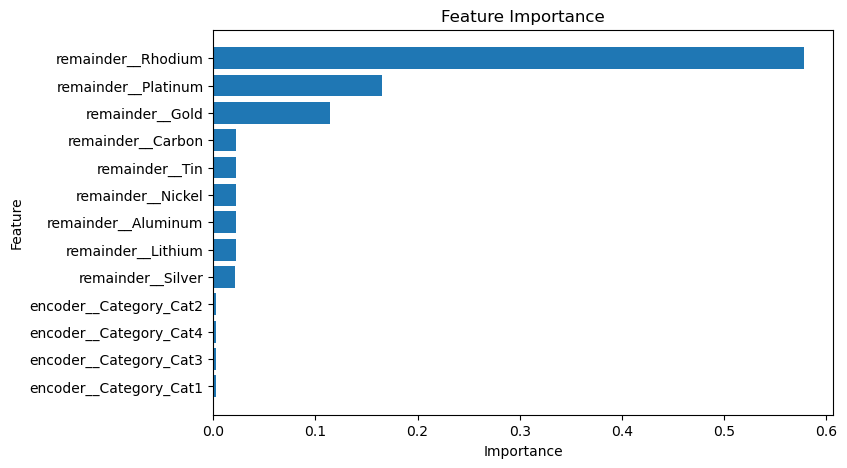

In [92]:
feature_importances = classifier.feature_importances_
feature_names = ct.get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [93]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}   
grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=5, n_jobs=-1,scoring="accuracy", verbose=1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print("Accuracy with Best Parameters:", accuracy_score(y_test, y_pred_best))
print("Classification Report with Best Parameters:\n", classification_report(y_test, y_pred_best))
print("Confusion Matrix with Best Parameters:\n", confusion_matrix(y_test, y_pred_best))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy with Best Parameters: 0.9765
Classification Report with Best Parameters:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1307
           1       0.98      0.95      0.97       693

    accuracy                           0.98      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix with Best Parameters:
 [[1296   11]
 [  36  657]]


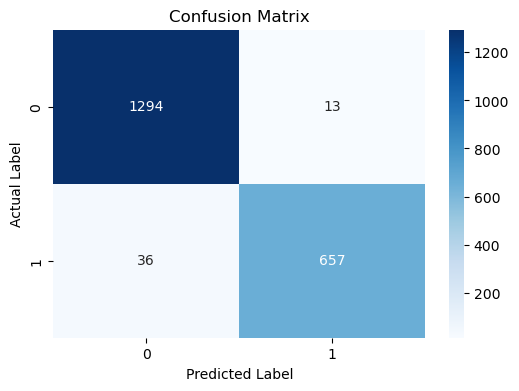

In [94]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

Note:  Feature importance bias (a known issue)

RandomForest importance sometimes overestimates features with larger variance.

A better way to verify this is Permutation Importance.

In [95]:
from sklearn.inspection import permutation_importance

result = permutation_importance(classifier, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print(perm_importance)

                   Feature    Importance
7       remainder__Rhodium  3.583500e-01
6      remainder__Platinum  1.420500e-01
4          remainder__Gold  9.960000e-02
12       remainder__Carbon  2.150000e-03
8        remainder__Nickel  1.600000e-03
11     remainder__Aluminum  1.250000e-03
1   encoder__Category_Cat2  7.000000e-04
5        remainder__Silver  6.000000e-04
3   encoder__Category_Cat4  3.500000e-04
2   encoder__Category_Cat3  5.000000e-05
10      remainder__Lithium  3.330669e-17
0   encoder__Category_Cat1 -2.000000e-04
9           remainder__Tin -9.000000e-04


Permutation feature importance was used to understand the contribution of each feature to the model's predictions. The results showed that Rhodium, Platinum, and Gold had the highest influence on predicting whether an electronic component is recoverable. This is reasonable because these metals have high economic value in recycling processes. Other metals such as Tin, Lithium, and Aluminum showed very low or negligible importance, indicating that they contribute minimally to the recoverability decision.